In [1]:
## LOAD DATASET

import os
import sys
import numpy as np
import librosa
import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

EMOTIONS = {"angry", "disgust", "fearful", "happy", "neutral", "sad"}
LABEL_TO_IDX = {label:idx for idx, label in enumerate(sorted(EMOTIONS))}
IDX_TO_LABEL = {idx:label for label, idx in LABEL_TO_IDX.items()}
NUM_CLASSES = len(LABEL_TO_IDX)
CREMAD_ROOT = r"CREMA-D"

CREMAD_EMOTION_MAP = {
    "ANG": "angry",
    "DIS": "disgust",
    "FEA": "fearful",
    "HAP": "happy",
    "NEU": "neutral",
    "SAD": "sad",
}


# CREMA-D file format: 1001_DFA_ANG_XX.wav
# split name into parts[]
# parts[2] is the 3-letter emotion code
def parse_cremad_filename(filepath):
    name = os.path.splitext(os.path.basename(filepath))[0]
    parts = name.split("_")
    emotion_code = parts[2]
    emotion_str = CREMAD_EMOTION_MAP.get(emotion_code)
    return emotion_str, LABEL_TO_IDX[emotion_str]


# AUDIO SETTINGS
SAMPLE_RATE   = 22050
MAX_DURATION  = 3.0
N_MELS        = 64
HOP_LENGTH    = 512
N_FFT         = 1024
TARGET_FRAMES = int(np.ceil(MAX_DURATION*SAMPLE_RATE/HOP_LENGTH))


# create a spectrogram from one file
def extract_logmel(filepath) -> np.ndarray:
    y,sr = librosa.load(filepath, sr=SAMPLE_RATE, mono=True)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    return log_mel.astype(np.float32)

    
# collate function for variable-length spectrograms
# pytorch default collate requires all tensors in a batch to be the same shape
# we pad shorter spectrograms on the right with zeros to match the longest clip in each batch
# zero padding is only within-batch, so the model never sees unnecessary silence
# across the whole dataset, only within batches where clips happen to vary in length
def collate_fn(batch):
    xs,ys = zip(*batch)
    max_t = max(x.shape[2] for x in xs)
    xs_padded = torch.stack([F.pad(x, (0,max_t-x.shape[2])) for x in xs])
    ys = torch.stack(ys)
    return xs_padded,ys


# DATASET CLASS
class SERDataset(Dataset):
    
    def __init__(self, file_list: list, parser, augment: bool=False, normalize: bool=True):

        # preload all spectrograms into memory at init time for faster training
        # this avoids repeated disk reads during training at the cost of RAM
        # for CREMA-D (~7400 files at float32 64*T), total memory is manageable (~2-3GB)
        self.preprocessed=[]
        self.filepaths=[]
        self.augment = augment
        self.normalize = normalize

        for f in file_list:
            
            result = parser(f)
            if result is not None:
                
                _, class_idx = result
                logmel = extract_logmel(f)
                
                self.preprocessed.append((logmel, class_idx))
                self.filepaths.append(f)

    def __len__(self):
        return len(self.preprocessed)
        
    def __getitem__(self, idx):
        
        logmel, label = self.preprocessed[idx]
        x = torch.tensor(logmel, dtype=torch.float32).unsqueeze(0)

        if self.augment:
            x = self.apply_augmentations(x)
        
        if self.normalize:
            x = (x-x.mean()) / (x.std()+1e-6)

        y = torch.tensor(label, dtype=torch.long)
        
        return x,y

    def apply_augmentations(self, x):

        # each augmentation applied independently so not every sample gets all augmentations every epoch
        # x.clone() prevents in-place modification of the cached spectrogram
        x = x.clone()
        
        if torch.rand(1).item()>0.5:
            x = self.freq_mask(x, max_mask_pct=0.4)    # mask random frequency band
            
        if torch.rand(1).item()>0.5:
            x = self.time_mask(x, max_mask_pct=0.2)    # mask random time block
            
        if torch.rand(1).item()>0.3:
            x = self.add_noise(x, noise_level=0.5)     # add gaussian noise
            
        if torch.rand(1).item()>0.3:
            x = self.shift_time(x, max_shift=5)        # shift frames slightly in time
        
        return x

    
    # zero out a random horizontal band of mel bins (aka. SpecAugment frequency masking)
    # forces model not to rely on specific frequency ranges, i.e. good for preventing overfitting
    def freq_mask(self, x, max_mask_pct:float=0.4):
        
        n_mels = x.shape[1]
        mask_size = int(n_mels*max_mask_pct)
        
        if mask_size<n_mels:
            f0 = torch.randint(0, n_mels-mask_size, (1,)).item()
            x[:, f0:f0 + mask_size,:] = 0
            
        return x


    # zero out a random vertical block of time frames (SpecAugment time masking)
    # forces model to recognize emotion even with part of utterance missing
    def time_mask(self, x, max_mask_pct:float=0.2):
        
        n_frames = x.shape[2]
        mask_size = int(n_frames*max_mask_pct)
        
        if mask_size < n_frames:
            t0 = torch.randint(0, n_frames-mask_size, (1,)).item()
            x[:, :, t0:t0 + mask_size] = 0
            
        return x

    # gaussian noise
    def add_noise(self, x, noise_level:float=0.5):
        noise = torch.randn_like(x)*noise_level
        return x+noise

    # randomly shift spectrogram slightly in time using circular roll
    # simulates small timing variations in speech onset
    def shift_time(self, x, max_shift:int=5):
        shift = torch.randint(-max_shift, max_shift, (1,)).item()
        return torch.roll(x, shifts=shift, dims=2)

# collect all .wav file paths from the flat CREMA-D directory
def get_cremad_files(cremad_root) -> list:
    files = [ os.path.join(cremad_root, f) for f in sorted(os.listdir(cremad_root)) if f.endswith(".wav")]
    return files
    
# split all CREMA-D files into train/val/test with seed=42
# so evaluate.py loads exactly the same test set as train.py
def make_cremad_splits(cremad_root:str, val_size:float=0.15, test_size:float=0.15, seed:int=42):
    
    all_files = get_cremad_files(cremad_root)
    train_val, test_files = train_test_split(all_files, test_size=test_size, random_state=seed)
    relative_val = val_size / (1.0-test_size)
    train_files, val_files = train_test_split(train_val, test_size=relative_val, random_state=seed)
    print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

    # augmentation only on training set, val and test must reflect real-world conditions
    train_ds = SERDataset(train_files, parser=parse_cremad_filename, augment=True,  normalize=True)
    val_ds = SERDataset(val_files, parser=parse_cremad_filename, augment=False, normalize=True)
    test_ds = SERDataset(test_files, parser=parse_cremad_filename, augment=False, normalize=True)
    
    return train_ds, val_ds, test_ds


# sanity check
if __name__ == "__main__":
    
    if len(sys.argv)<2:
        print("Usage: python dataset.py <path_to_cremad_root>")
        sys.exit(1)

    train_ds, val_ds, test_ds = make_cremad_splits(CREMAD_ROOT)
    x,y = train_ds[0]
    
    print(f"\nSample shape : {x.shape}")
    print(f"Label index  : {y.item()} -> {IDX_TO_LABEL[y.item()]}")
    print(f"Num classes  : {NUM_CLASSES}")
    print(f"Label map    : {LABEL_TO_IDX}")

    loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, collate_fn=collate_fn)
    xb,yb = next(iter(loader))
    
    print(f"\nBatch x shape: {xb.shape}")
    print(f"Batch y shape: {yb.shape}")

Train: 5208 | Val: 1117 | Test: 1117

Sample shape : torch.Size([1, 64, 103])
Label index  : 1 -> disgust
Num classes  : 6
Label map    : {'angry': 0, 'disgust': 1, 'fearful': 2, 'happy': 3, 'neutral': 4, 'sad': 5}

Batch x shape: torch.Size([16, 1, 64, 146])
Batch y shape: torch.Size([16])


In [2]:
## MODEL
import torch.nn as nn

# a single convolutional block: Conv -> BatchNorm -> ReLU -> MaxPool -> Dropout
# each block doubles the number of feature channels while halving spatial dimensions
# BatchNorm stabilizes training by normalizing activations within each batch
# MaxPool2d(2) halves both frequency and time dimensions each block
# After 3 blocks: freq 64 -> 32 -> 16 -> 8, time T -> T/2 -> T/4 -> T/8
class ConvBlock(nn.Module):
    
    def __init__(self, in_channels:int, out_channels:int, dropout:float=0.2):
        
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(dropout),
        )
        
    def forward(self, x):
        return self.block(x)


# CRNN for Speech Emotion Recognition
# Pipeline: log-mel spectrogram -> CNN (local features) -> GRU (temporal dynamics) -> classifier
#
# Input:      (batch, 1, 64, T) - 1 channel, 64 mel bins, T time frames (variable length)
# Output:  (batch, num_classes) - raw logits, one per emotion class
class CRNN(nn.Module):
    
    def __init__(self, num_classes:int=NUM_CLASSES, gru_hidden:int=128, gru_layers:int=2, dropout:float=0.3):
        
        super().__init__()

        # CNN encoder, 3 convolutional blocks, channels 1 -> 32 -> 64 -> 128
        self.cnn = nn.Sequential(
            ConvBlock(1,32, dropout=dropout), 
            ConvBlock(32,64, dropout=dropout), 
            ConvBlock(64,128, dropout=dropout))

        # after 3 blocks, freq dimension: 64/2^3 = 8
        # GRU input at each time step = channels * freq bins = 128*8 = 1024
        cnn_out_freq = 8
        cnn_out_channels = 128
        gru_input_size = cnn_out_channels*cnn_out_freq

        # bidirectional GRU: reads sequence forward and backward for richer context
        # 2 stacked layers allow hierarchical temporal modeling
        # output size per time step: gru_hidden*2 = 256 (bidirectional doubles it)
        self.gru = nn.GRU(
            input_size=gru_input_size,
            hidden_size=gru_hidden, 
            num_layers=gru_layers, 
            batch_first=True, 
            dropout=dropout if gru_layers>1 else 0.0, 
            bidirectional=True,
        )

        # classifier: dropout for regularization, linear layer maps to emotion classes
        self.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(gru_hidden*2, num_classes))

    
    def forward(self, x:torch.Tensor) -> torch.Tensor:

        # extract local features from spectrogram
        x = self.cnn(x)

        # reshape for GRU, treat time axis as sequence, flatten (channels * freq) into features
        batch, channels, freq, time = x.shape
        x = x.permute(0,3,1,2)                        # (batch, time, channels, freq)
        x = x.reshape(batch, time, channels*freq)     # (batch, time, 1024)

        # model temporal dynamics across the sequence
        x,_ = self.gru(x)

        # IMPORTANT: Global average pooling: average across all time steps -> (batch, 256)
        # handles variable-length inputs naturally, no padding bias
        # each time step contributes equally regardless of clip length
        x = x.mean(dim=1)
        x = self.classifier(x)
        return x

# this part is just sanity check
if __name__ == "__main__":
    
    model = CRNN(num_classes=NUM_CLASSES)
    print(f"Model: \n\n{model}")
    
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTrainable parameters: {n_params:,}")
    
    dummy = torch.randn(16,1,64,130)
    out = model(dummy)
    print(f"Input shape:  {dummy.shape}")
    print(f"Output shape: {out.shape}")

Model: 

CRNN(
  (cnn): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (4): Dropout2d(p=0.3, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (4): Dropout2d(p=0.3, inplace=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, m

Using device: cuda

Train: 5208 | Val: 1117 | Test: 1117
Model parameters: 1,277,382

Epoch   1/1000 | Train loss: 1.7235  acc: 0.259 | Val loss: 1.5729  acc: 0.349 | 2.0s
Saved best model (val loss: 1.5729)
Epoch   2/1000 | Train loss: 1.6069  acc: 0.321 | Val loss: 1.4718  acc: 0.401 | 1.7s
Saved best model (val loss: 1.4718)
Epoch   3/1000 | Train loss: 1.5727  acc: 0.339 | Val loss: 1.4717  acc: 0.403 | 1.7s
Saved best model (val loss: 1.4717)
Epoch   4/1000 | Train loss: 1.5343  acc: 0.375 | Val loss: 1.4189  acc: 0.411 | 1.7s
Saved best model (val loss: 1.4189)
Epoch   5/1000 | Train loss: 1.5352  acc: 0.361 | Val loss: 1.4643  acc: 0.399 | 1.7s
Epoch   6/1000 | Train loss: 1.5120  acc: 0.373 | Val loss: 1.4364  acc: 0.405 | 1.7s
Epoch   7/1000 | Train loss: 1.5082  acc: 0.374 | Val loss: 1.3938  acc: 0.422 | 1.6s
Saved best model (val loss: 1.3938)
Epoch   8/1000 | Train loss: 1.4892  acc: 0.388 | Val loss: 1.3798  acc: 0.433 | 1.6s
Saved best model (val loss: 1.3798)
Epoch   9/

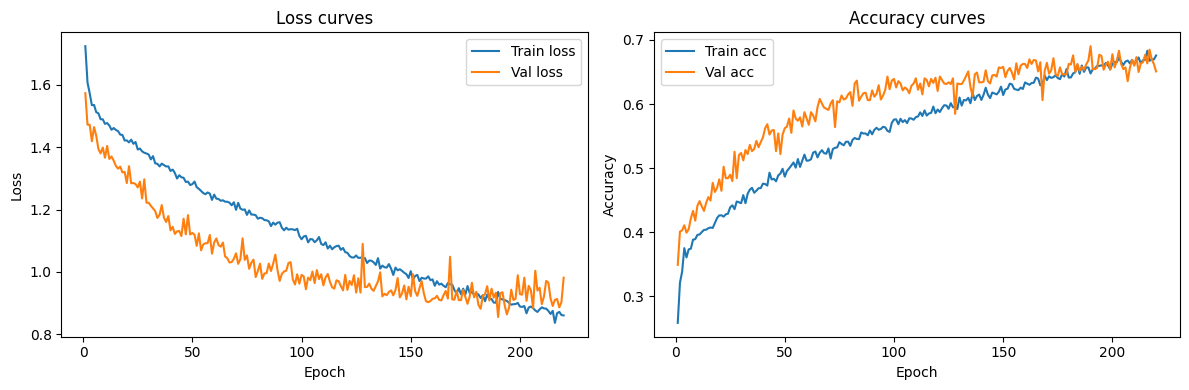

Saved training_curves.png

Evaluating best model on test set...
Test loss: 0.7981 | Test accuracy: 0.710


In [3]:
## TRAINING

import time
import matplotlib.pyplot as plt

CHECKPOINT    = "best_model.pt"
BATCH_SIZE    = 32
NUM_EPOCHS    = 1000
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4              # L2 regularization to reduce overfitting
PATIENCE      = 30                # early stopping, halt if val loss doesnt improve for this many epochs
NUM_WORKERS   = 0
PIN_MEMORY    = True              # faster CPU -> GPU transfer when using CUDA

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# single pass over the dataset, if training=True, backprop and update weights
def run_epoch(model, loader, criterion, optimizer, device, training:bool):
    
    model.train() if training else model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # disable gradient computation during validation to save memory and speed up inference
    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = logits.argmax(dim=1)
            total_correct += (preds==y).sum().item()
            total_samples += y.size(0)
            total_loss += loss.item()*y.size(0)          # accumulate sum, divide at end for true mean

    avg_loss = total_loss/total_samples
    accuracy = total_correct/total_samples
    return avg_loss, accuracy


# plot loss and accuracy curves side by side and save as .png
def plot_curves(train_losses, val_losses, train_accs, val_accs):
    
    epochs = range(1, len(train_losses)+1)
    fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,4))
    
    ax1.plot(epochs, train_losses, label="Train loss")
    ax1.plot(epochs, val_losses, label="Val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Loss curves")
    ax1.legend()
    
    ax2.plot(epochs, train_accs, label="Train acc")
    ax2.plot(epochs, val_accs, label="Val acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("Accuracy curves")
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("Saved training_curves.png")

def train():
    
    print(f"Using device: {DEVICE}\n")
    train_ds, val_ds, test_ds = make_cremad_splits(CREMAD_ROOT)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

    model = CRNN(num_classes=NUM_CLASSES).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model parameters: {n_params:,}\n")

    # CrossEntropyLoss: standard for multi-class classification, expects raw logits
    criterion = nn.CrossEntropyLoss()

    # Adam optimizer: adaptive learning rates per parameter, reliable default for deep learning
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # cosine annealing with warm restarts: LR cycles between LEARNING_RATE and eta_min
    # T_0=10 means first cycle is 10 epochs, T_mult=2 doubles each subsequent cycle
    # warm restarts help escape local minima and often find better solutions
    scheduler = scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)

    train_losses, val_losses = [],[]
    train_accs, val_accs = [],[]
    best_val_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(1, NUM_EPOCHS+1):
        
        t0 = time.time()
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, DEVICE, training=True)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer, DEVICE, training=False)
        
        scheduler.step(val_loss)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        elapsed = time.time()-t0
        
        print(
            f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
            f"Train loss: {train_loss:.4f}  acc: {train_acc:.3f} | "
            f"Val loss: {val_loss:.4f}  acc: {val_acc:.3f} | "
            f"{elapsed:.1f}s"
        )

        # save checkpoint whenever val loss improves, ensures best_model.pt
        # always contains the best weights regardless of when training stops
        if val_loss<best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), CHECKPOINT)
            print(f"Saved best model (val loss: {best_val_loss:.4f})")
            epochs_no_improve=0
            
        else:
            epochs_no_improve+=1

        # early stopping
        if epochs_no_improve>=PATIENCE:
            print(f"\nEarly stopping triggered after {epoch} epochs.")
            break

    # this part is the sanity check
    print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")
    plot_curves(train_losses, val_losses, train_accs, val_accs)

    print("\nEvaluating best model on test set...")
    model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
    
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
    test_loss, test_acc = run_epoch(model, test_loader, criterion, optimizer, DEVICE, training=False)
    print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.3f}")

if __name__ == "__main__":
    train()

Using device: cuda

Train: 5208 | Val: 1117 | Test: 1117
Test samples: 1117

Loaded checkpoint: best_model.pt

  Accuracy : 0.710  (71.0%)
  UAR      : 0.715  (71.5%)
  F1 score : 0.707  (weighted)

Per-class report:
              precision    recall  f1-score   support

       angry      0.757     0.817     0.786       191
     disgust      0.726     0.613     0.665       194
     fearful      0.621     0.728     0.670       180
       happy      0.742     0.680     0.710       194
     neutral      0.728     0.863     0.790       161
         sad      0.695     0.589     0.637       197

    accuracy                          0.710      1117
   macro avg      0.711     0.715     0.710      1117
weighted avg      0.712     0.710     0.707      1117



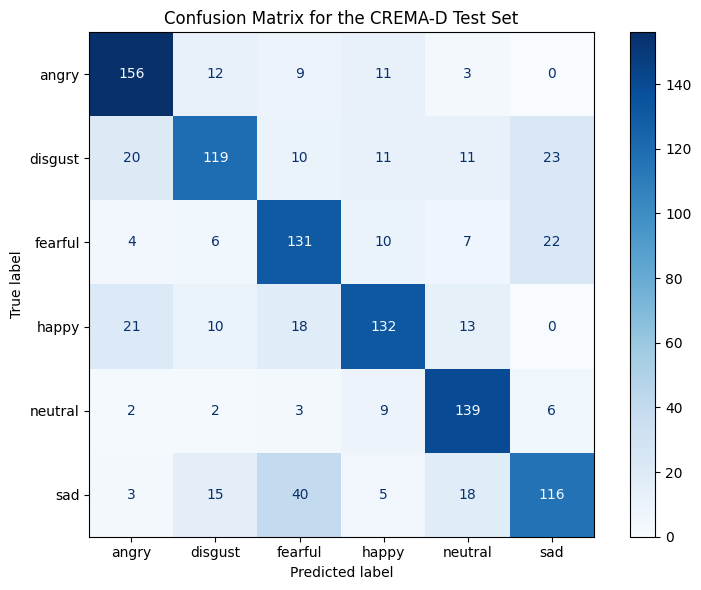


Generating top confusion analysis...
Top 3 most common misclassification pairs:
  True: fearful  -> Pred: sad       (sentence: IEO, 9 errors)
  True: disgust  -> Pred: angry     (sentence: IEO, 8 errors)
  True: fearful  -> Pred: angry     (sentence: IEO, 8 errors)


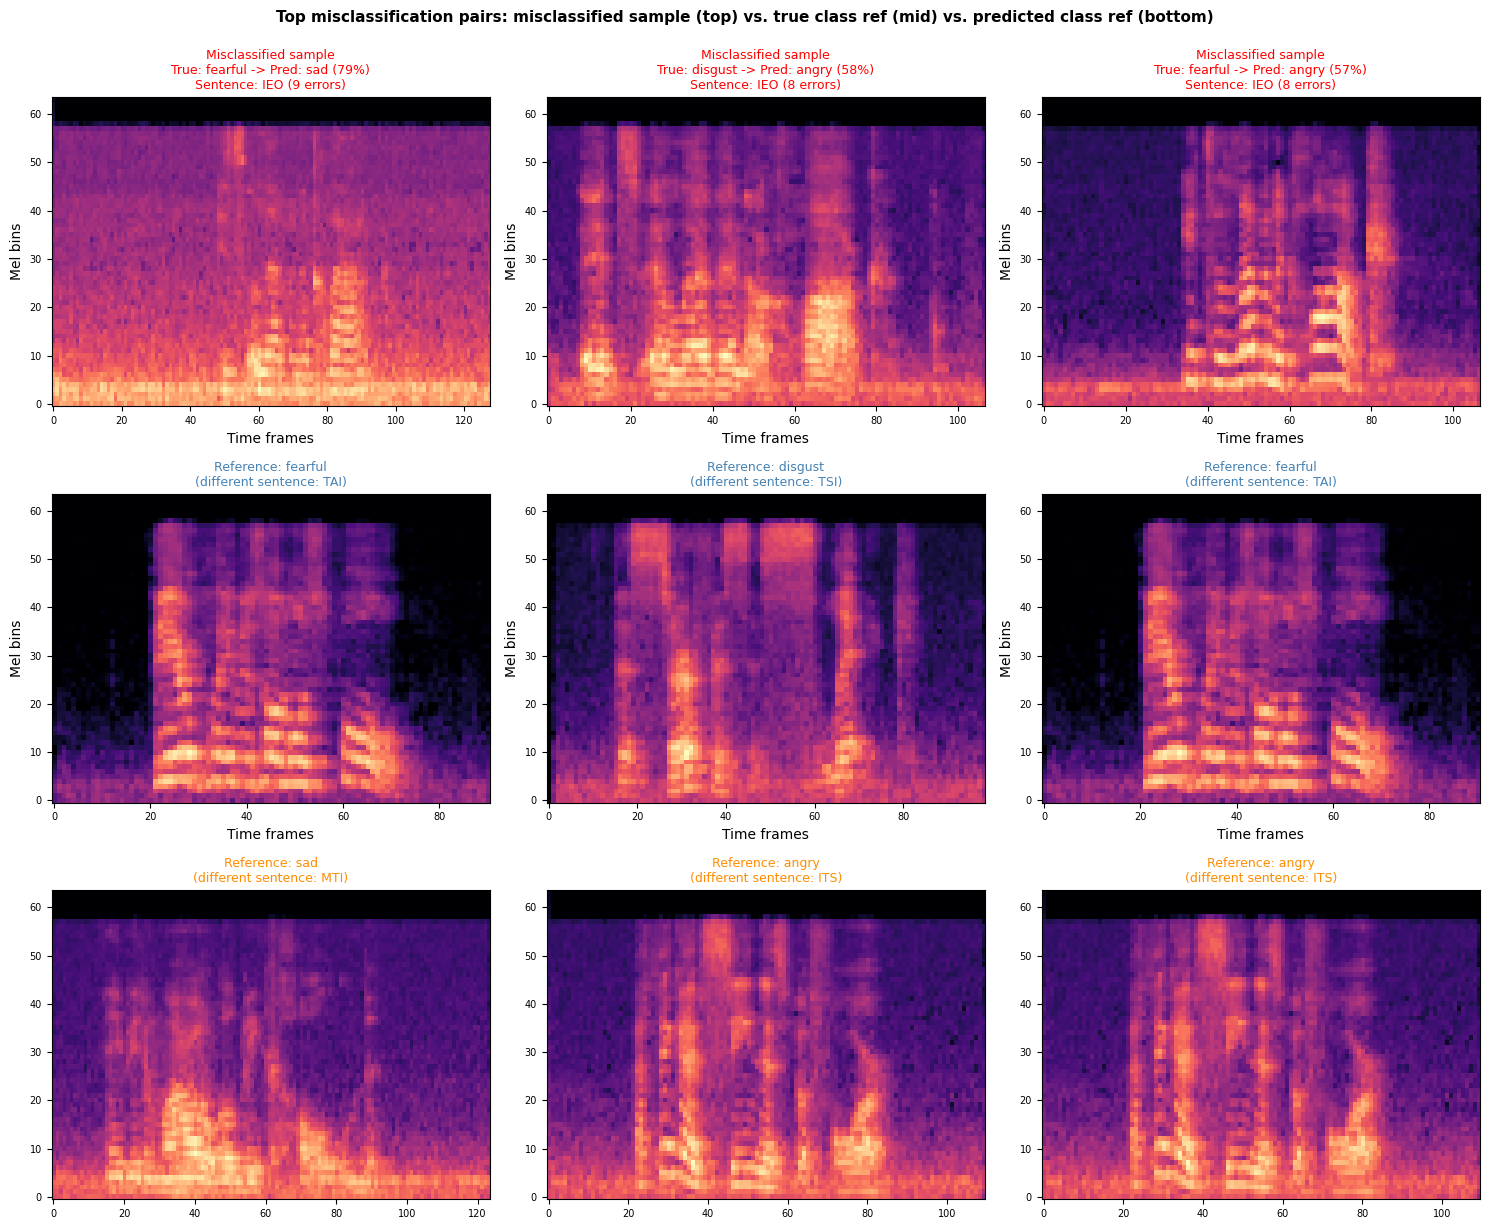

Saved top_confusions.png



In [4]:
# EVALUATION

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, classification_report, ConfusionMatrixDisplay
from IPython.display import display, Audio, HTML
from collections import defaultdict

# reconstruct model architecture and load saved weights
def load_model(checkpoint_path):
    model = CRNN(num_classes=NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()
    return model


# run full inference over the test set, collect all predictions and true labels
def get_all_predictions(model, loader):
    
    all_preds=[]
    all_labels=[]
 
    with torch.no_grad():
        for x,y in loader:
            x=x.to(DEVICE)
            logits=model(x)
            preds=logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(y.numpy())
 
    return np.concatenate(all_preds), np.concatenate(all_labels)


# compute and print metrics required by the project brief: accuracy, UAR, and weighted F1
def print_metrics(preds, labels):
 
    accuracy = (preds==labels).mean()
    
    label_names = [IDX_TO_LABEL[i] for i in range(NUM_CLASSES)]
    report = classification_report(labels, preds, target_names=label_names, digits=3)
    
    cm = confusion_matrix(labels, preds)
    per_class_recall = cm.diagonal()/cm.sum(axis=1)
    uar = per_class_recall.mean()
    
    f1 = f1_score(labels, preds, average="weighted")
 
    print("="*50)
    print(f"  Accuracy : {accuracy:.3f}  ({accuracy*100:.1f}%)")
    print(f"  UAR      : {uar:.3f}  ({uar*100:.1f}%)")
    print(f"  F1 score : {f1:.3f}  (weighted)")
    print("="*50)
    print("\nPer-class report:")
    print(report)
 
    return cm, label_names


#         confusion matrix heatmap: 
#
#            rows = true labels
#         columns = predicted labels
#        diagonal = correct predictions
#    off-diagonal = confusions between classes
#
def plot_confusion_matrix(cm, label_names):
    fig, ax = plt.subplots(figsize=(8,6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=True, cmap="Blues")
    ax.set_title("Confusion Matrix for the CREMA-D Test Set")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()


# build a reference gallery: one random sample per emotion class
# used in the bottom row to compare misclassified samples against
# what each emotion typically looks like


def show_top_confusions(model, test_ds, n_pairs=3):

    confusion_examples = defaultdict(list)

    for idx in range(len(test_ds)):
        
        x, true_label = test_ds[idx]
        with torch.no_grad():
            logit = model(x.unsqueeze(0).to(DEVICE))
            probs = torch.softmax(logit, dim=1).cpu().numpy()[0]
            pred_label = int(probs.argmax())

        if pred_label != true_label.item():
            
            basename = os.path.basename(test_ds.filepaths[idx])
            parts = basename.split('_')
            
            if len(parts) >= 2:
                sentence_id = parts[1]
            else:
                sentence_id = "unknown"
            
            confusion_examples[(true_label.item(), pred_label, sentence_id)].append({
                "filepath": test_ds.filepaths[idx],
                "true_label": true_label.item(),
                "pred_label": pred_label,
                "confidence": float(probs[pred_label]),
                "spectrogram": x.squeeze(0).numpy(),
                "sentence": sentence_id,
            })

    sorted_pairs = sorted(confusion_examples.items(), key=lambda x: len(x[1]), reverse=True)
    top_pairs = sorted_pairs[:n_pairs]

    print(f"Top {n_pairs} most common misclassification pairs:")
    for (true_cls, pred_cls, sentence), examples in top_pairs:
        print(f"  True: {IDX_TO_LABEL[true_cls]:8s} -> Pred: {IDX_TO_LABEL[pred_cls]:8s}  (sentence: {sentence}, {len(examples)} errors)")

    class_indices = {i: [] for i in range(NUM_CLASSES)}
    for idx in range(len(test_ds)):
        _, label = test_ds[idx]
        class_indices[label.item()].append(idx)

    # Build reference samples with different sentences
    reference_samples = {}
    same_sentence_samples = {}
    
    for (true_cls, pred_cls, mis_sentence), examples in top_pairs:
        
        # reference for true class, different sentence
        for idx in range(len(test_ds)):
            
            x, label = test_ds[idx]
            if label.item() == true_cls:
                
                filepath = test_ds.filepaths[idx]
                basename = os.path.basename(filepath)
                parts = basename.split('_')
                
                if len(parts) >= 2:
                    sentence = parts[1]
                    
                    if sentence != mis_sentence:
                        reference_samples[(true_cls, "true")] = {
                            "filepath": filepath,
                            "spectrogram": x.squeeze(0).numpy(),
                            "sentence": sentence,
                        }
                        
                        break
        
        # reference for predicted class, different sentence
        for idx in range(len(test_ds)):
            x, label = test_ds[idx]
            if label.item() == pred_cls:
                filepath = test_ds.filepaths[idx]
                basename = os.path.basename(filepath)
                parts = basename.split('_')
                if len(parts) >= 2:
                    sentence = parts[1]
                    if sentence != mis_sentence:
                        reference_samples[(pred_cls, "pred")] = {
                            "filepath": filepath,
                            "spectrogram": x.squeeze(0).numpy(),
                            "sentence": sentence,
                        }
                        break
        
        # samples for the same sentence for both emotions
        for idx in range(len(test_ds)):
            
            x, label = test_ds[idx]
            if label.item() == true_cls:
                
                filepath = test_ds.filepaths[idx]
                basename = os.path.basename(filepath)
                parts = basename.split('_')
                
                if len(parts) >= 2 and parts[1] == mis_sentence:
                    same_sentence_samples[(true_cls, mis_sentence)] = {
                        "filepath": filepath,
                        "spectrogram": x.squeeze(0).numpy(),
                        "sentence": mis_sentence,
                    }
                    break
        
        for idx in range(len(test_ds)):
            
            x, label = test_ds[idx]
            if label.item() == pred_cls:
                
                filepath = test_ds.filepaths[idx]
                basename = os.path.basename(filepath)
                parts = basename.split('_')
                
                if len(parts) >= 2 and parts[1] == mis_sentence:
                    same_sentence_samples[(pred_cls, mis_sentence)] = {
                        "filepath": filepath,
                        "spectrogram": x.squeeze(0).numpy(),
                        "sentence": mis_sentence,
                    }
                    break

    fig, axes = plt.subplots(3, n_pairs, figsize=(5*n_pairs, 12))

    for col, ((true_cls, pred_cls, mis_sentence), examples) in enumerate(top_pairs):
        
        sample = examples[0]
        true_str = IDX_TO_LABEL[true_cls]
        pred_str = IDX_TO_LABEL[pred_cls]
        n_errors = len(examples)

        ax = axes[0, col]
        ax.imshow(sample["spectrogram"], origin="lower", aspect="auto", cmap="magma")
        ax.set_title(
            f'Misclassified sample\nTrue: {true_str} -> Pred: {pred_str} ({sample["confidence"]:.0%})\nSentence: {mis_sentence} ({n_errors} errors)',
            color="red", fontsize=9
        )
        ax.set_xlabel("Time frames"); ax.set_ylabel("Mel bins"); ax.tick_params(labelsize=7)

        ax = axes[1, col]
        ref_true = reference_samples.get((true_cls, "true"))
        
        if ref_true:
            ax.imshow(ref_true["spectrogram"], origin="lower", aspect="auto", cmap="magma")
            ax.set_title(f'Reference: {true_str}\n(different sentence: {ref_true["sentence"]})', color="steelblue", fontsize=9)
            
        else:
            ax.text(0.5, 0.5, f'No reference found\nfor {true_str}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Reference: {true_str}', color="steelblue", fontsize=9)
            
        ax.set_xlabel("Time frames"); ax.set_ylabel("Mel bins"); ax.tick_params(labelsize=7)

        ax = axes[2, col]
        ref_pred = reference_samples.get((pred_cls, "pred"))
        
        if ref_pred:
            ax.imshow(ref_pred["spectrogram"], origin="lower", aspect="auto", cmap="magma")
            ax.set_title(f'Reference: {pred_str}\n(different sentence: {ref_pred["sentence"]})', color="darkorange", fontsize=9)
            
        else:
            ax.text(0.5, 0.5, f'No reference found\nfor {pred_str}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Reference: {pred_str}', color="darkorange", fontsize=9)

        ax.tick_params(labelsize=7)

    fig.text(0.5, 1.01,
             "Top misclassification pairs: misclassified sample (top) vs. true class ref (mid) vs. predicted class ref (bottom)",
             ha="center", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig("top_confusions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved top_confusions.png\n")

    display(HTML("<h3>Top misclassification pairs - audio</h3>"))
    for col, ((true_cls, pred_cls, mis_sentence), examples) in enumerate(top_pairs):
        sample = examples[0]
        true_str = IDX_TO_LABEL[true_cls]
        pred_str = IDX_TO_LABEL[pred_cls]

        display(HTML(f'<h4>Pair {col+1}: True {true_str} -> Predicted {pred_str} ({len(examples)} errors)</h4>'))
        display(HTML(f'<b style="color:red">Misclassified sample</b>'))
        display(Audio(sample["filepath"]))
        
        ref_true = reference_samples.get((true_cls, "true"))
        if ref_true:
            display(HTML(f'<b>Reference: {true_str} (different sentence: {ref_true["sentence"]})</b>'))
            display(Audio(ref_true["filepath"]))
        else:
            display(HTML(f'<b>Reference: {true_str}</b>'))
            display(HTML(f'<i>No sample with different sentence found</i>'))
        
        ref_pred = reference_samples.get((pred_cls, "pred"))
        if ref_pred:
            display(HTML(f'<b>Reference: {pred_str} (different sentence: {ref_pred["sentence"]})</b>'))
            display(Audio(ref_pred["filepath"]))
        else:
            display(HTML(f'<b>Reference: {pred_str}</b>'))
            display(HTML(f'<i>No sample with different sentence found</i>'))
        
        same_true = same_sentence_samples.get((true_cls, mis_sentence))
        same_pred = same_sentence_samples.get((pred_cls, mis_sentence))
        
        if same_true or same_pred:
            display(HTML(f'<b style="color:green">Same sentence ({mis_sentence}) references for comparison:</b>'))
            if same_true:
                display(HTML(f'<span>{true_str}:</span>'))
                display(Audio(same_true["filepath"]))
            if same_pred:
                display(HTML(f'<span>{pred_str}:</span>'))
                display(Audio(same_pred["filepath"]))


def evaluate():
    
    print(f"Using device: {DEVICE}\n")
    _, _, test_ds = make_cremad_splits(CREMAD_ROOT, seed=42)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
    print(f"Test samples: {len(test_ds)}\n")
 
    model = load_model(CHECKPOINT)
    print(f"Loaded checkpoint: {CHECKPOINT}\n")

    preds, labels = get_all_predictions(model, test_loader)
    cm, label_names = print_metrics(preds, labels)
 
    plot_confusion_matrix(cm, label_names)

    print("\nGenerating top confusion analysis...")
    show_top_confusions(model, test_ds, n_pairs=3)
 
if __name__ == "__main__":
    evaluate()